[2026-08-05 10:48:27] [info     ] 合规检查                           columns=['date', 'instrument', 'factor'] duplicate_keys=0 has_inf=False rows=238311 trading_days=242
[2026-08-05 10:48:27] [info     ] 每日覆盖数量                         maximum=999 mean=984.7561983471074 minimum=863
[2026-08-05 10:48:27] [info     ] 因子分布                           summary={'count': 238311.0, 'mean': 0.00013521498829270956, 'std': 0.3293780770105383, 'min': -1.7493216762273984, '25%': -0.1932191051800626, '50%': 0.0, '75%': 0.19335860120216167, 'max': 1.6787037473234065}
[2026-08-05 10:48:27] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 10:48:29] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 10:48:30] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 10:48:30] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 10:48:30] [info     ] ========== 数据检查 ==========
[2026-08-05 10:48:30] [info     ] 通过：列名检查（date/ins

时段,IC
2024-01-15~2024-02-08,0.0144
2024-09-24~2024-10-08,0.0049

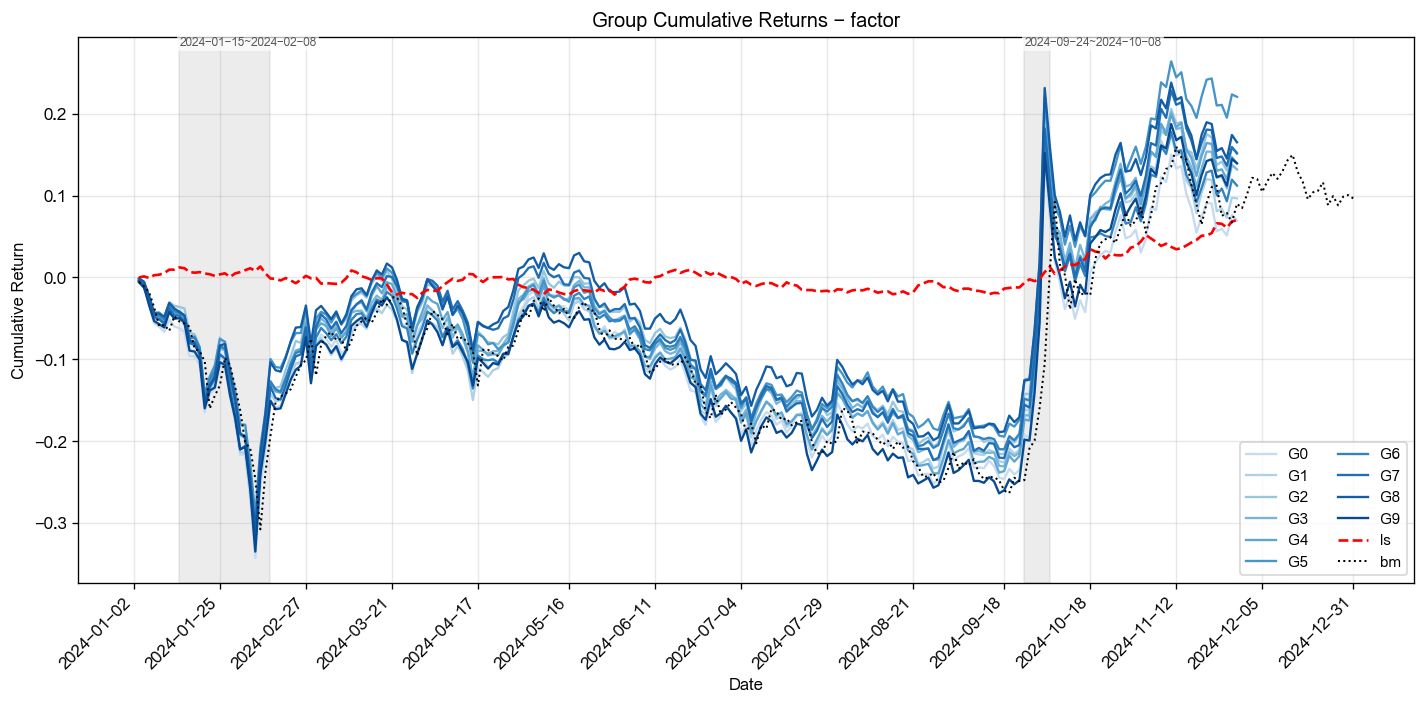
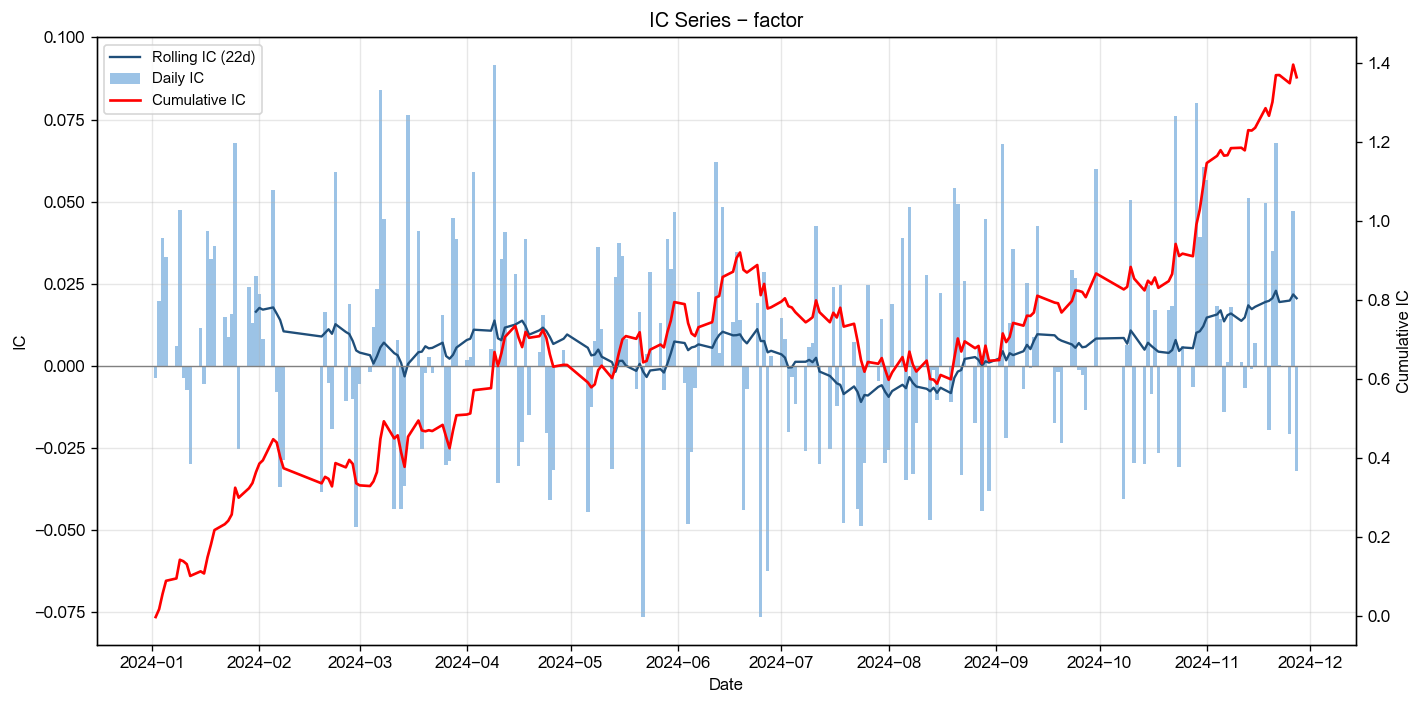
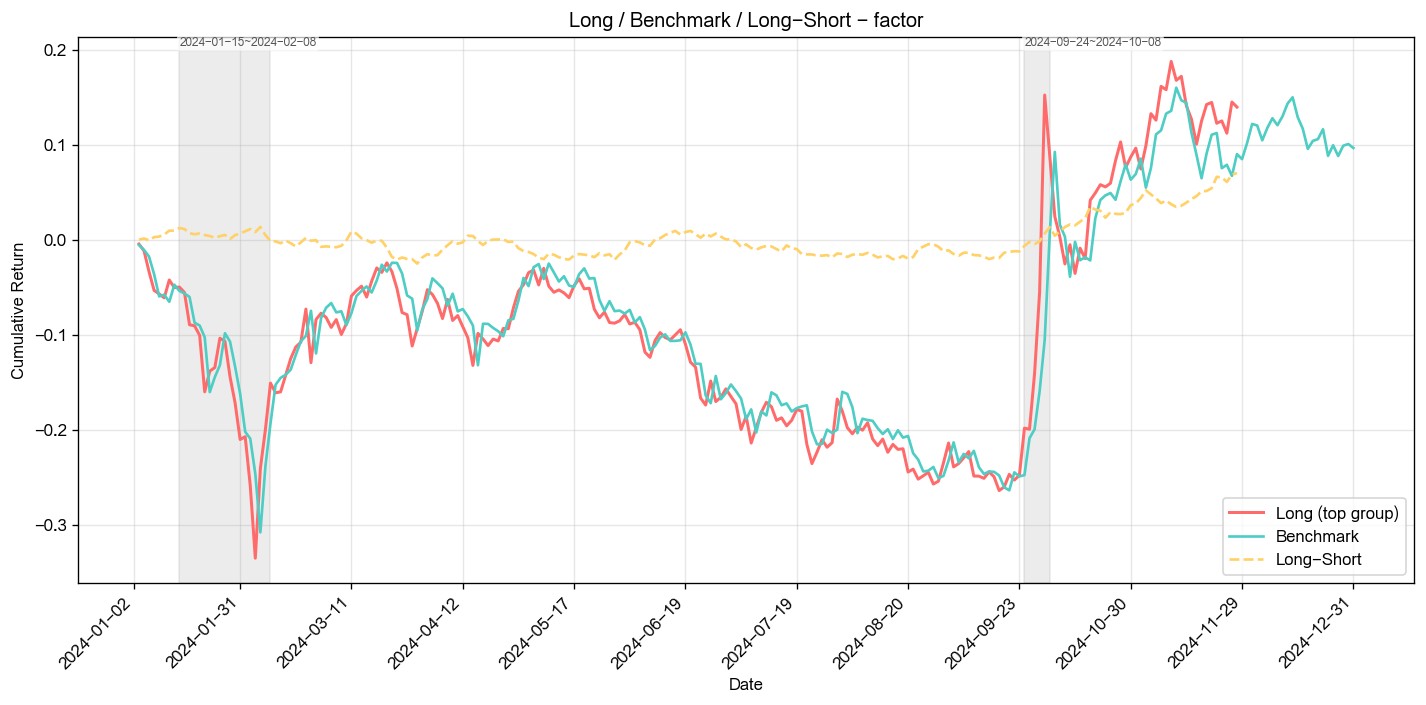
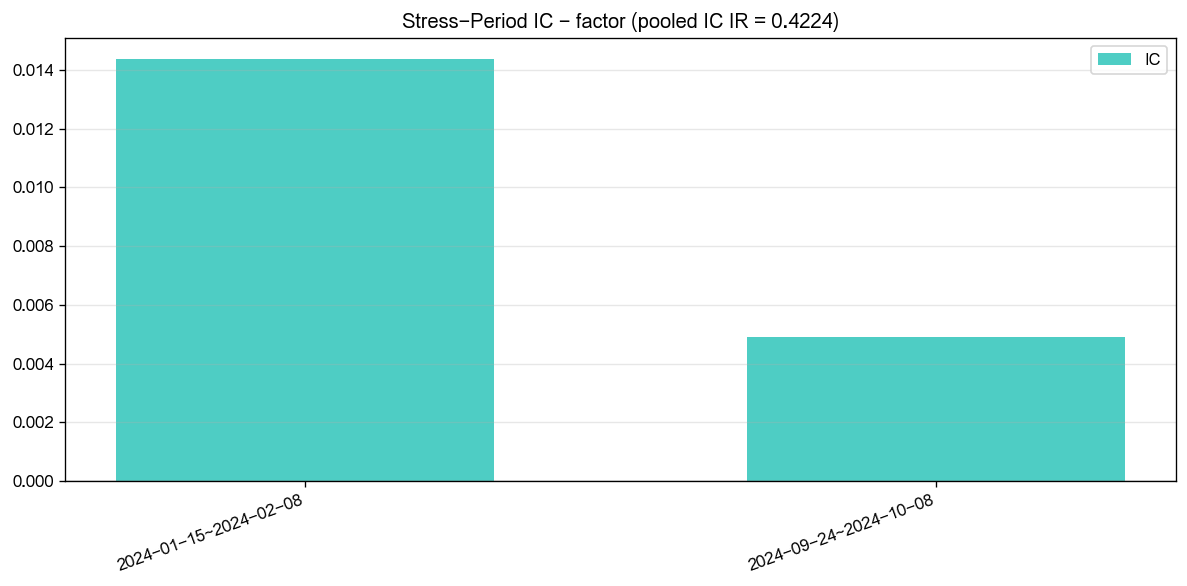
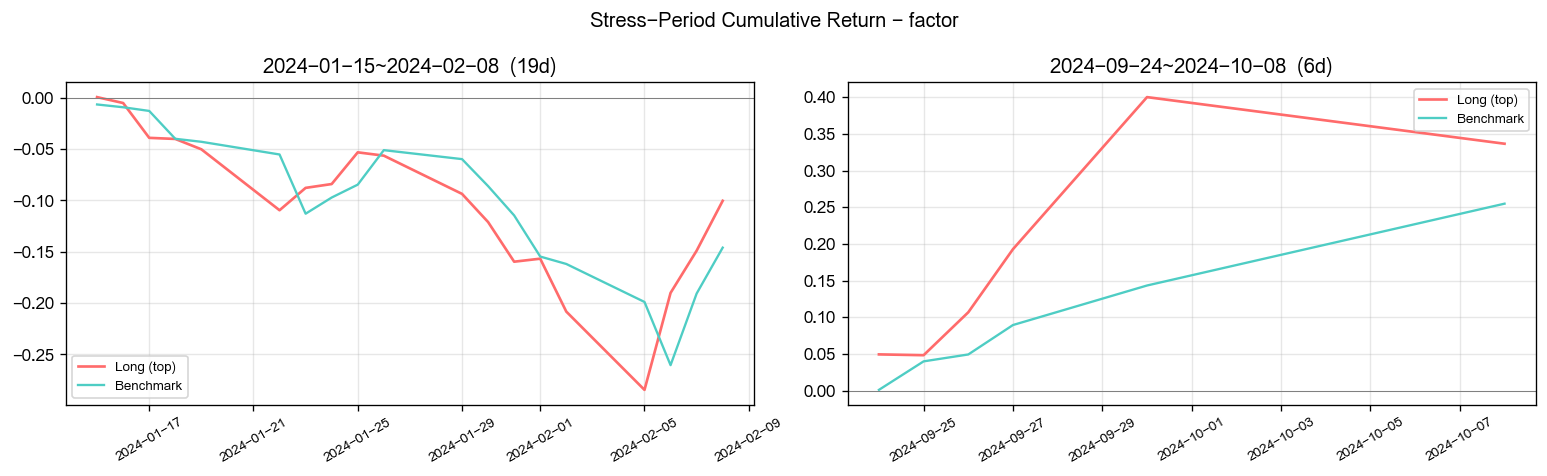

[2026-08-05 10:48:55] [info     ] ========== 因子池回归 ==========
[2026-08-05 10:48:55] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 10:48:56] [info     ] 获取收益率数据, 耗时: 0.8213 秒
[2026-08-05 10:48:56] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.7241 秒
[2026-08-05 10:48:56] [info     ] 统计 回归结果, 耗时: 0.0063 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,1.9797,0.0046,0.0023,1.0000
2,rsi_12,1.8691,0.0437,0.0234,1.0000
3,amount,1.7525,0.0209,0.0119,1.0000
4,netflow_amount_main,1.6969,0.0258,0.0152,1.0000
5,gross_profit_rate_ttm,1.4975,0.0070,0.0047,0.9000
6,bias_20,1.4349,0.0299,0.0208,1.0000
7,volume,1.3636,0.0141,0.0104,1.0000
8,cci_14,1.3590,0.0316,0.0233,0.9000
9,netflow_amount_rate_main,1.3554,0.0088,0.0065,1.0000
10,net_profit_rate_ttm,1.3298,0.0039,0.0029,0.9000

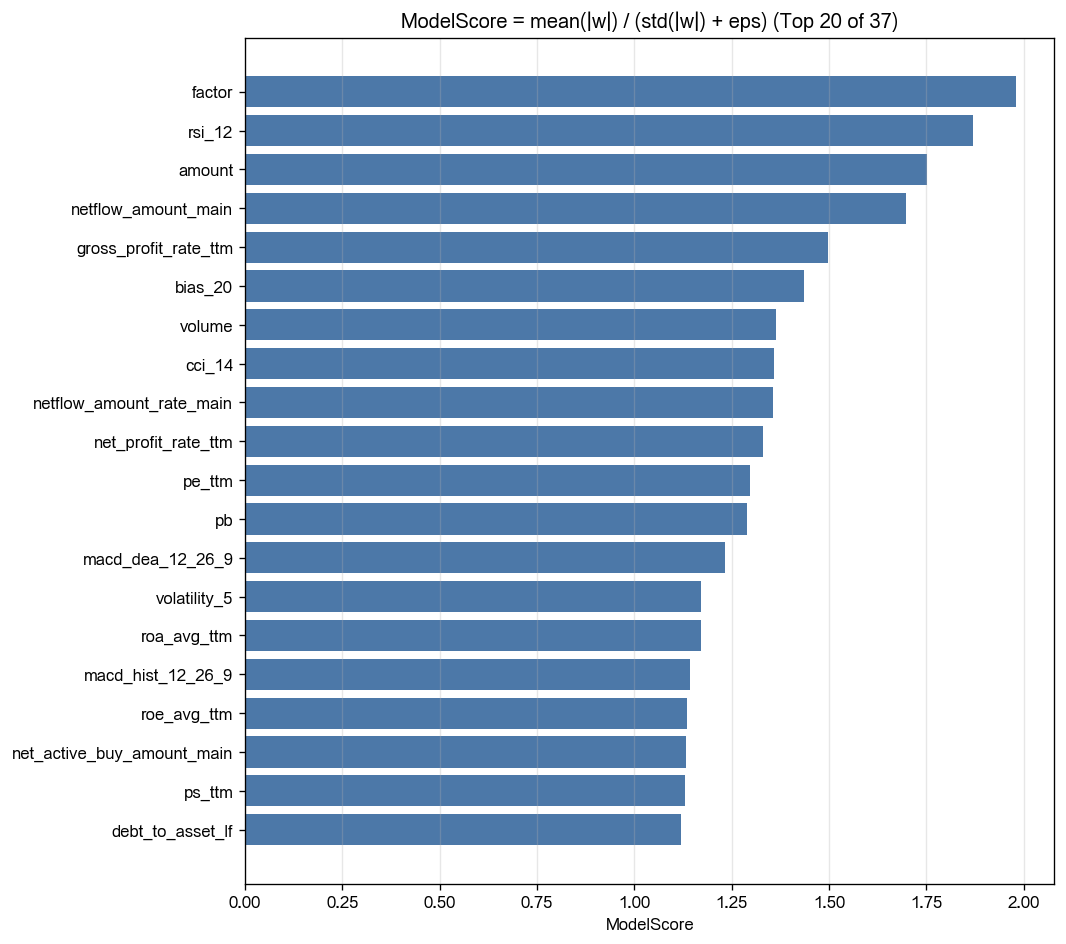
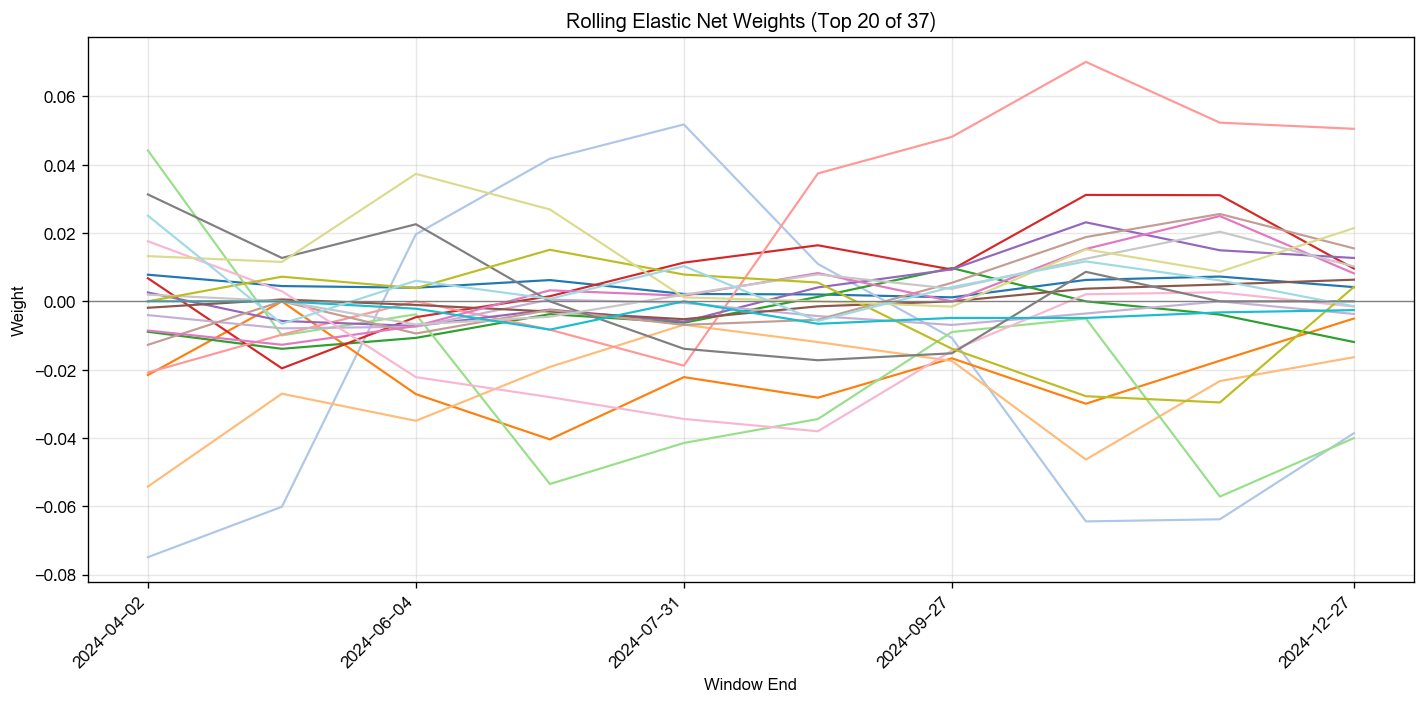
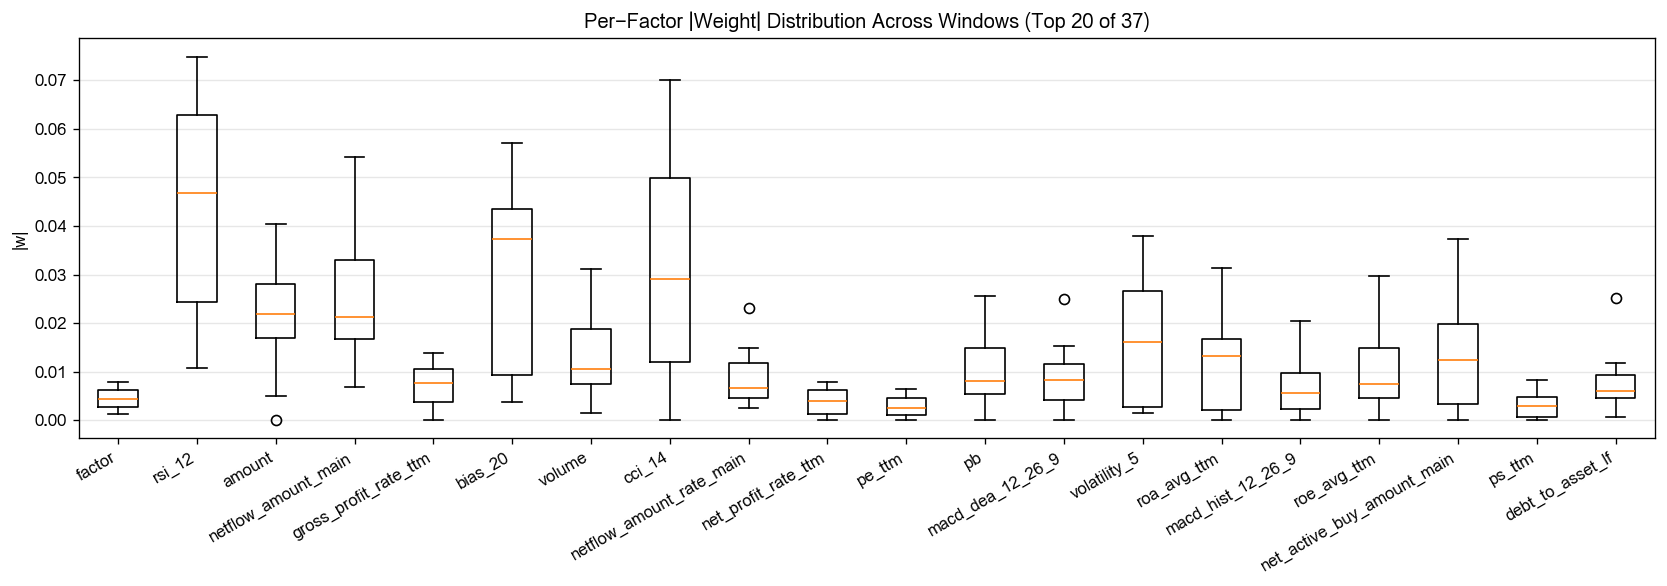
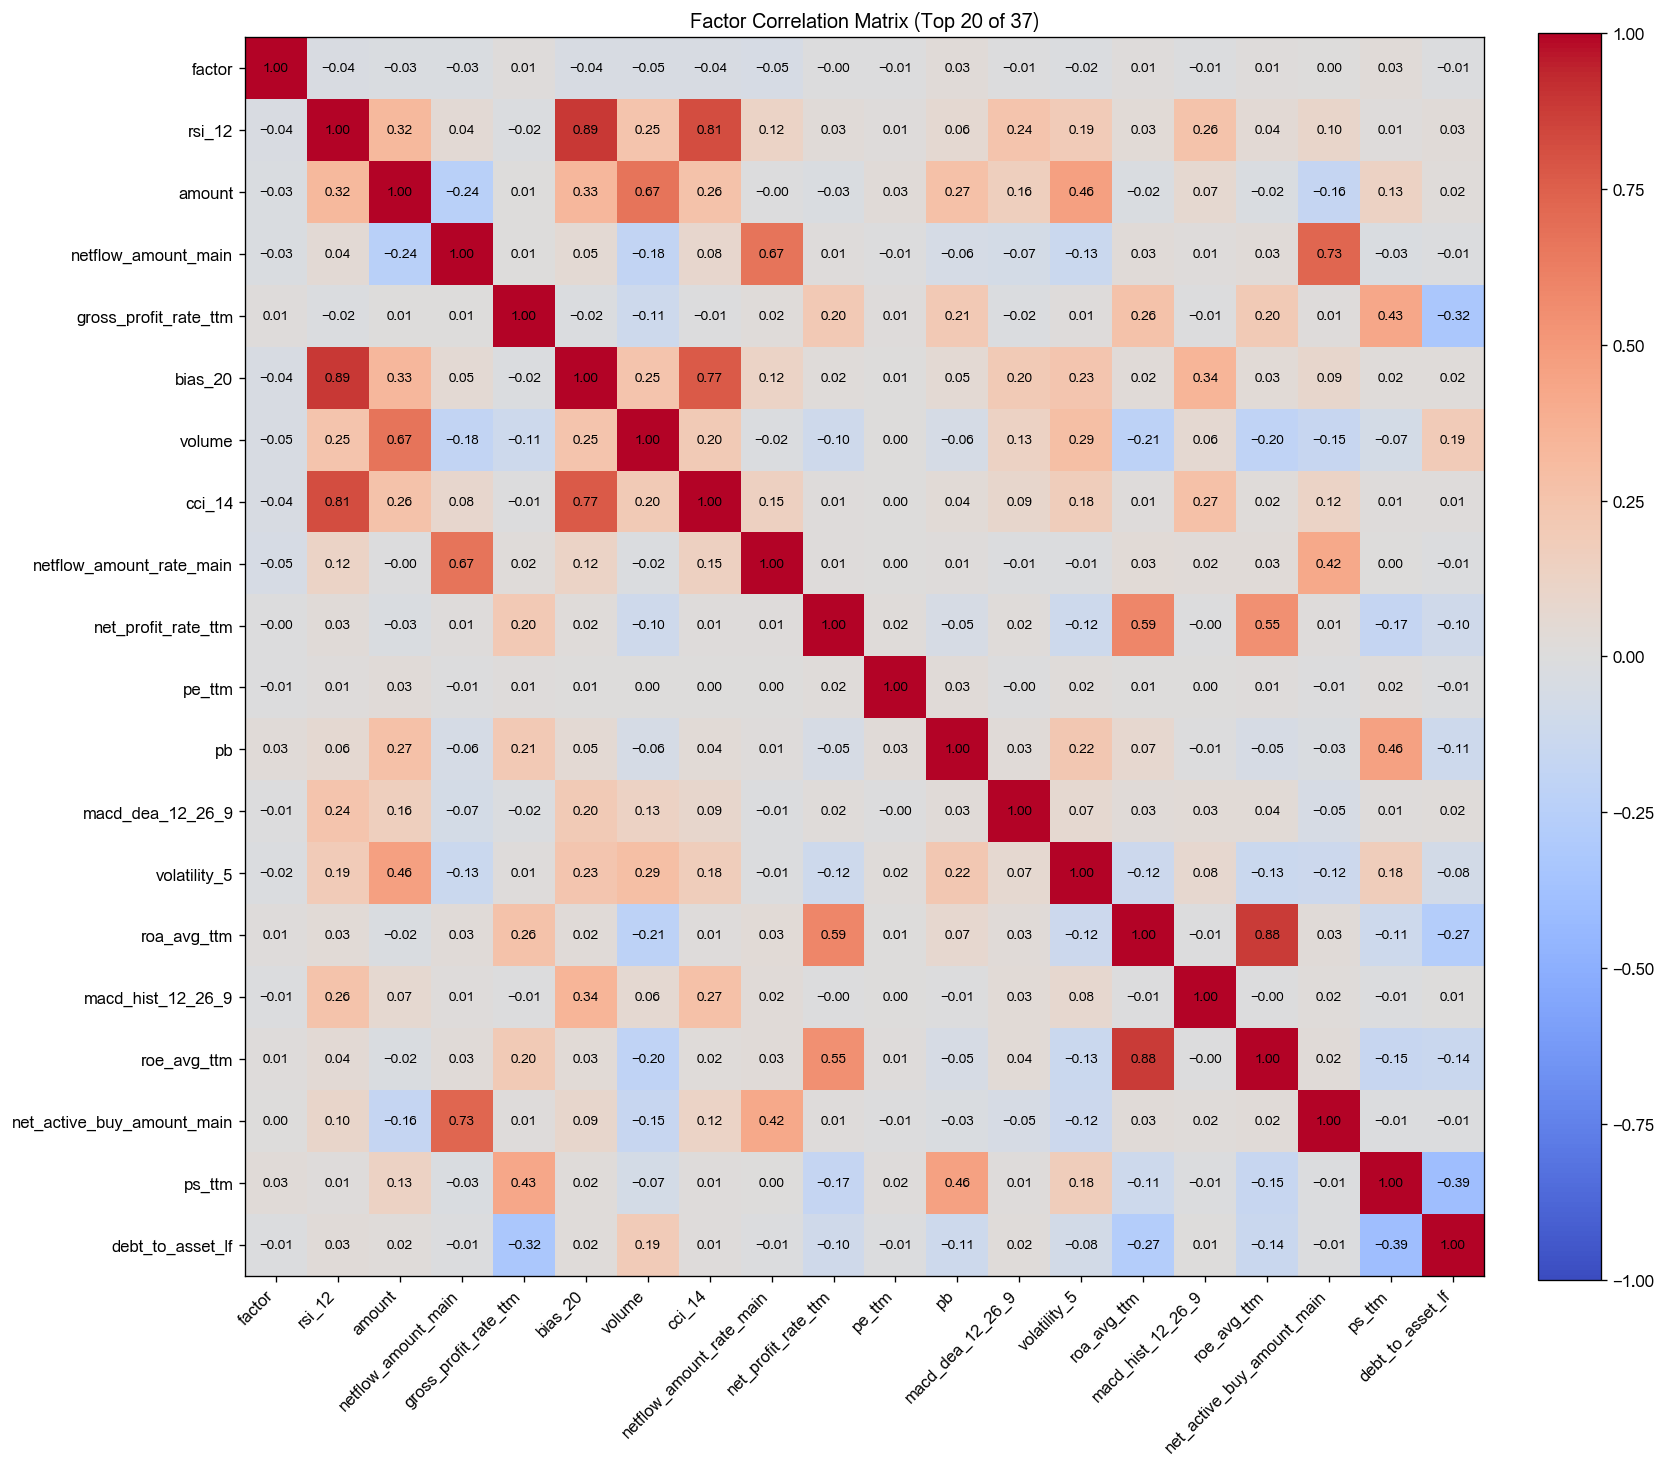

[2026-08-05 10:48:58] [warning  ] 返回的Outputs实例(size=34287371) 大于 64K, 将不会被缓存
[2026-08-05 10:48:58] [info     ] bigalpha_eval.v4 运行完成 [28.596s].


In [2]:
AI_APPLICATION_NOTES = r"""
# TPPD-C3 v1：AI 技术应用与研究记录

## 赛道标签

AI 智能赛道。

## 因子摘要

TPPD-C3（Tail Pressure–Price Decoupling Continuation, 3-Day Smoothed）研究尾盘盘口压力与价格响应之间的脱钩。因子不直接使用订单簿失衡水平，而是识别尾盘订单压力相对 14:00–14:29 基准窗口的突变，并判断该压力是否获得价格的同方向确认；最终信号使用 3 个有效交易日均值降低换手。

若买方压力显著增强但中间价尚未充分上涨，推断买方需求可能在次日继续兑现，因子给出正向信号；卖方压力增强但价格尚未充分下跌时，因子给出负向信号。

## AI 参与环节

本因子由 OpenAI Codex 参与完成赛制分析、既有因子诊断、假设生成、公式设计、SQL 实现和合规检查设计：

1. 解析比赛的 A/B 评分结构，确认 Elastic Net 增量贡献占最终得分 70%。
2. 对既有 TWOBI-S 因子与官方 `factor_hf` 模板进行结构比对，识别出二者均以五档加权订单簿失衡及反转方向为核心，推断随着全局因子池扩张，其 B 项可能受到同类因子挤压。
3. 将优化目标从“调整盘口档位权重或平滑窗口”改为“提取盘口压力与价格响应的非线性脱钩信息”。
4. 设计压力突变、波动率及价差缩放后的价格响应、每日截面排序，以及只在价格未充分确认盘口压力时激活的非线性信号函数。
5. 在截面排序前连接当日中证 1000 股票池，避免历史成分股污染每日百分位排名。
6. 输出阶段以官方中证 1000 股票池为母表；对停牌、单边盘口或有效分钟不足而无法形成信号的股票填入中性值 0，确保单日增量评测覆盖合规。
7. 依据官方模板生成可自动运行的 DAI SQL 和 Python `main` 函数，并加入三列输出、无穷值、重复键及覆盖度检查。

人工负责核验研究假设、在 BigQuant 平台运行、读取官方评估结果并决定是否提交。首次 2024 年方向诊断显示原始反转方向的 IC、IC_IR、夏普和 Stress 全部为负，因此按统一证据将方向修正为延续；符号翻转不改变基于绝对回归权重的 ModelScore。方向修正后 IC、IC_IR 与 Stress 转正，但多空夏普仍为 -0.111，表明组合换手成本仍可能覆盖部分毛收益，因此引入 3 个有效交易日的轻度均值平滑。后续仍需进行跨年度验证，避免只依赖单一年度。

## 公式

五档加权盘口失衡：

\[
I_t=\frac{\sum_{k=1}^{5}e^{-0.3(k-1)}B_{k,t}-\sum_{k=1}^{5}e^{-0.3(k-1)}A_{k,t}}
{\sum_{k=1}^{5}e^{-0.3(k-1)}B_{k,t}+\sum_{k=1}^{5}e^{-0.3(k-1)}A_{k,t}+\epsilon}
\]

尾盘压力突变：

\[
Q_d=\overline I_{d,14:30-15:00}-\overline I_{d,14:00-14:29}
\]

经波动率和相对价差缩放的价格响应：

\[
R_d=\frac{\log(M_{d,end}/M_{d,start})}
{\sigma_{d,tail}+Spread_{d,tail}+\epsilon}
\]

对二者分别做每日截面百分位变换至 \([-1,1]\)，得到 \(q_d\) 和 \(r_d\)。最终信号为：

\[
F_d=q_d\max\left(|q_d|-\operatorname{sign}(q_d)r_d,0\right)
\]

当价格对盘口压力的同向确认足够强时，因子收缩至零；压力越极端且越不被价格确认，沿压力方向的延续信号越强。

日频原始信号再进行 3 个有效交易日均值：

\[
F^{(3)}_{i,d}=\frac{1}{N_{i,d}}\sum_{k=0}^{2}F_{i,d-k},\qquad N_{i,d}\leq 3
\]

窗口仅包含当前日及前两个有效观测，不使用未来数据。

## 提交前验证要求

1. 首先运行 2024 全年，确认输出仅有 `date`、`instrument`、`factor` 三列，无重复键和无穷值。
2. 核对每天覆盖数量及相对股票池的缺失率，最大缺失率必须不超过 40%。
3. 记录 IC、IC_IR、多空夏普和 Stress，但不只根据综合 A 项决定是否提交。
4. 重点读取本地 Elastic Net 的 ModelScore、非零窗口占比和滚动权重稳定性。
5. 查看与公开因子库、TWOBI-S 的相关性。若与 TWOBI-S 仍高度相关，应调整信息结构，而不是仅更改参数。
6. 至少分段检查 2019–2021、2022–2023、2024，避免再次只根据 2024 年决定方向和结构。

## 已知局限

- 盘口快照不能完整识别撤单、隐藏订单及真实主动成交方向，“吸收”属于基于可观测盘口与价格脱钩的推断。
- 每日截面排序提高了稳健性，但会舍弃压力幅度的部分信息。
- 停牌或尾盘有效快照不足的股票不会产生当日因子值，必须在平台核对覆盖率。
- 该版本尚未取得官方评估结果；任何效果数字都应在平台实际运行后补充，不应预先声称。

"""

"""
TPPD-C3 v1: 尾盘盘口压力—价格响应脱钩延续因子（3 日平滑）
Tail Pressure–Price Decoupling Continuation, 3-Day Smoothed

赛道：AI 智能赛道

核心逻辑：
1. 比较 14:00–14:29 与 14:30–15:00 的五档加权盘口失衡，得到尾盘压力突变；
2. 计算尾盘中间价收益，并用分钟波动率与相对价差缩放；
3. 在每日截面内分别对压力突变和价格响应做百分位排序；
4. 仅当盘口压力没有被价格同方向充分确认时，沿压力方向生成延续信号；
5. 对日频信号做 3 个有效交易日的均值平滑，降低换手成本。

若买方压力显著增强但价格尚未充分上涨，推断买方需求可能在次日继续兑现；
若卖方压力显著增强但价格尚未充分下跌，推断卖方压力可能在次日继续兑现。
"""


def main(datasources, start_date, end_date):
    """返回且仅返回 date / instrument / factor 三列。"""
    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    # 3 日窗口需要向前取历史。15 个自然日足以跨越常见周末与长假。
    query_start = str(pd.to_datetime(start_date) - pd.Timedelta(days=15))

    sql = f"""
    WITH valid_minutes AS (
        SELECT
            date,
            instrument,
            strftime(date, '%Y-%m-%d') AS trading_day,
            strftime(date, '%H%M') AS hhmm,
            (ask_price1 + bid_price1) / 2.0 AS mid_price,
            (ask_price1 - bid_price1)
                / ((ask_price1 + bid_price1) / 2.0 + 1e-8) AS relative_spread,
            (
                COALESCE(bid_volume1, 0) * 1.0 +
                COALESCE(bid_volume2, 0) * EXP(-0.3) +
                COALESCE(bid_volume3, 0) * EXP(-0.6) +
                COALESCE(bid_volume4, 0) * EXP(-0.9) +
                COALESCE(bid_volume5, 0) * EXP(-1.2)
            ) AS weighted_bid,
            (
                COALESCE(ask_volume1, 0) * 1.0 +
                COALESCE(ask_volume2, 0) * EXP(-0.3) +
                COALESCE(ask_volume3, 0) * EXP(-0.6) +
                COALESCE(ask_volume4, 0) * EXP(-0.9) +
                COALESCE(ask_volume5, 0) * EXP(-1.2)
            ) AS weighted_ask
        FROM {bar1m}
        WHERE strftime(date, '%H%M') >= '1400'
          AND strftime(date, '%H%M') <= '1500'
          AND ask_price1 > 0
          AND bid_price1 > 0
          AND ask_price1 >= bid_price1
    ),
    minute_features AS (
        SELECT
            *,
            (weighted_bid - weighted_ask)
                / (weighted_bid + weighted_ask + 1e-8) AS imbalance,
            LAG(mid_price, 1) OVER (
                PARTITION BY instrument, trading_day
                ORDER BY date
            ) AS previous_mid
        FROM valid_minutes
    ),
    pre_window AS (
        SELECT
            trading_day,
            instrument,
            AVG(imbalance) AS pre_imbalance,
            COUNT(*) AS pre_count
        FROM minute_features
        WHERE hhmm >= '1400' AND hhmm < '1430'
        GROUP BY trading_day, instrument
        HAVING COUNT(*) >= 15
    ),
    tail_window AS (
        SELECT
            trading_day,
            instrument,
            AVG(imbalance) AS tail_imbalance,
            ARG_MIN(mid_price, date) AS tail_first_mid,
            ARG_MAX(mid_price, date) AS tail_last_mid,
            AVG(relative_spread) AS tail_spread,
            NANSTD(
                CASE
                    WHEN mid_price > 0 AND previous_mid > 0
                    THEN LOG(mid_price / previous_mid)
                    ELSE NULL
                END
            ) AS tail_volatility,
            COUNT(*) AS tail_count
        FROM minute_features
        WHERE hhmm >= '1430' AND hhmm <= '1500'
        GROUP BY trading_day, instrument
        HAVING COUNT(*) >= 15
    ),
    daily_raw AS (
        SELECT
            CAST(p.trading_day AS DATETIME) AS date,
            p.instrument,
            t.tail_imbalance - p.pre_imbalance AS pressure_shock,
            LOG(t.tail_last_mid / t.tail_first_mid)
                / (
                    COALESCE(t.tail_volatility, 0) +
                    COALESCE(t.tail_spread, 0) +
                    1e-6
                ) AS price_response
        FROM pre_window p
        INNER JOIN tail_window t
            ON p.trading_day = t.trading_day
           AND p.instrument = t.instrument
        WHERE t.tail_first_mid > 0
          AND t.tail_last_mid > 0
          AND p.pre_imbalance IS NOT NULL
          AND t.tail_imbalance IS NOT NULL
    ),
    daily_in_pool AS (
        -- 截面排序必须先限定在当日中证 1000 成分股内，避免历史成分股污染排名母体。
        SELECT d.*
        FROM daily_raw d
        INNER JOIN bigalpha_2026_instruments u
            ON d.date = u.date
           AND d.instrument = u.instrument
    ),
    cross_sectional_ranks AS (
        SELECT
            date,
            instrument,
            2.0 * PERCENT_RANK() OVER (
                PARTITION BY date ORDER BY pressure_shock
            ) - 1.0 AS pressure_rank,
            2.0 * PERCENT_RANK() OVER (
                PARTITION BY date ORDER BY price_response
            ) - 1.0 AS response_rank
        FROM daily_in_pool
        WHERE pressure_shock IS NOT NULL
          AND price_response IS NOT NULL
    ),
    final_signal AS (
        SELECT
            date,
            instrument,
            -- confirmation > 0 表示价格与盘口压力同向；
            -- 只保留未被价格充分确认的压力，并沿压力延续方向赋值。
            pressure_rank * GREATEST(
                ABS(pressure_rank) - SIGN(pressure_rank) * response_rank,
                0.0
            ) AS factor
        FROM cross_sectional_ranks
    ),
    smoothed_signal AS (
        SELECT
            date,
            instrument,
            AVG(factor) OVER (
                PARTITION BY instrument
                ORDER BY date
                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
            ) AS factor
        FROM final_signal
    )
    SELECT date, instrument, factor
    FROM smoothed_signal
    ORDER BY date, instrument
    """

    df = dai.query(
        sql,
        filters={"date": [query_start, end_date]},
        compression=True,
    ).df()

    # 官方模板允许固定使用该股票池表；公榜/私榜无需替换。
    stock_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()

    df["date"] = pd.to_datetime(df["date"])
    stock_pool["date"] = pd.to_datetime(stock_pool["date"])
    df["instrument"] = df["instrument"].astype(str)
    stock_pool["instrument"] = stock_pool["instrument"].astype(str)

    # 以官方股票池为母表。隐藏评测可能只传入单个交易日；若个别股票因停牌、
    # 单边盘口或有效分钟不足未生成信号，填入截面中性值 0，避免覆盖度失效。
    result = pd.merge(
        stock_pool,
        df[["date", "instrument", "factor"]],
        how="left",
        on=["date", "instrument"],
    )
    result["factor"] = pd.to_numeric(result["factor"], errors="coerce")
    result["factor"] = result["factor"].replace([np.inf, -np.inf], np.nan)
    result["factor"] = result["factor"].fillna(0.0)

    return (
        result[["date", "instrument", "factor"]]
        .sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )


if __name__ == "__main__":
    import numpy as np
    import dai
    import structlog
    from bigmodule import M

    logger = structlog.get_logger()
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    factor_data = main(datasources, start_date, end_date)

    logger.info(
        "合规检查",
        rows=len(factor_data),
        columns=list(factor_data.columns),
        trading_days=factor_data["date"].nunique(),
        has_inf=bool(np.isinf(factor_data["factor"]).any()),
        duplicate_keys=int(
            factor_data.duplicated(["date", "instrument"]).sum()
        ),
    )
    daily_coverage = factor_data.groupby("date")["instrument"].nunique()
    logger.info(
        "每日覆盖数量",
        minimum=int(daily_coverage.min()),
        mean=float(daily_coverage.mean()),
        maximum=int(daily_coverage.max()),
    )
    logger.info("因子分布", summary=factor_data["factor"].describe().to_dict())

    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
